In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import glob
import seaborn as sns

In [3]:
def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['lat']))
    weighted_da = da * weights
    return weighted_da


def reshape_to_2d(da):
    """Reshape (lat, lon, time) data into 2D matrix (space x time)."""
    space_dim = da['lat'].size * da['lon'].size
    reshaped = da.stack(space=('lat', 'lon')).transpose('time', 'space')
    return reshaped


def compute_covariance_matrix(reshaped_da):
    """Compute the covariance matrix of the data."""
    data = reshaped_da.values
    data = data - np.nanmean(data, axis=0)  # Centering the data
    covariance_matrix = np.cov(data.T)
    return covariance_matrix


def perform_svd(cov_matrix):
    """Perform SVD on the covariance matrix."""
    U, S, Vt = np.linalg.svd(cov_matrix)
    return U, S, Vt


def plot_first_principal_component(reshaped_da, Vt):
    """Plot the first principal component as a map."""
    first_pc = Vt[0, :] #first eigenvector with largest eigenvalue
    pc_map = reshaped_da.isel(time=0).copy() #.isel selects the i you give, make a copy of given array at i
    pc_map.values = first_pc #change the values from before to the first_pc values
    pc_map_unstacked = pc_map.unstack('space')

    plt.figure(figsize=(8, 5))
    pc_map_unstacked.plot(cmap='RdBu')
    plt.title("First Principal Component (Spatial Pattern)")
    plt.show()

    return pc_map_unstacked


def compute_zonal_mean(pc_map_unstacked):
    """Compute the zonal mean of the first principal component map."""
    zonal_mean = pc_map_unstacked.mean(dim='lon')
    return zonal_mean


def make_zonal_mean_map(zonal_mean, da):
    """Create a zonal mean map, assigning each longitude the same value."""
    zonal_map = xr.zeros_like(da.isel(time=0)) #blank map with same dimensions as da
    for lon in zonal_map['lon']:
        zonal_map.loc[{'lon': lon}] = zonal_mean #assign zonal mean value to each longitude
    return zonal_map


def regress_onto_zonal_mean_map(da, zonal_map):
    """Regress original data onto the zonal mean map (time series of coefficients)."""
#flattening data
    zonal_map_flat = zonal_map.stack(space=('lat', 'lon')).values
    data_flat = da.stack(space=('lat', 'lon')).transpose('time', 'space').values
#detrending by removing mean
    zonal_map_flat = zonal_map_flat - np.nanmean(zonal_map_flat)
    data_flat = data_flat - np.nanmean(data_flat, axis=0)

    regression_coefficients = np.dot(data_flat, zonal_map_flat) / np.dot(zonal_map_flat, zonal_map_flat)

    return regression_coefficients


def plot_regression_coefficients(time, regression_coefficients):
    """Plot regression coefficients over time."""
    plt.figure(figsize=(8, 5))
    plt.plot(time, regression_coefficients, label='Regression Coefficients')
    plt.xlabel('Time')
    plt.ylabel('Coefficient')
    plt.title('Regression Coefficients Over Time')
    plt.grid()
    plt.show()
    
def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

In [4]:
u1=xr.open_dataset('/climca/data/ERA5/daily/u50hpa/E5pl00_1D_1960-05_131.nc')
u1

<xarray.Dataset> Size: 102MB
Dimensions:  (time: 31, lon: 1280, lat: 640, plev: 1)
Coordinates:
  * time     (time) datetime64[ns] 248B 1960-05-01T11:30:00 ... 1960-05-31T11...
  * lon      (lon) float64 10kB 0.0 0.2812 0.5625 0.8438 ... 359.2 359.4 359.7
  * lat      (lat) float64 5kB 89.78 89.51 89.23 88.95 ... -89.23 -89.51 -89.78
  * plev     (plev) float64 8B 5e+03
Data variables:
    var131   (time, plev, lat, lon) float32 102MB ...
Attributes:
    CDI:          Climate Data Interface version 2.0.5 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Tue Apr 02 12:52:09 2024: cdo -O -s -r -b 32 -f nc4 -z zip ...
    CDO:          Climate Data Operators version 2.0.5 (https://mpimet.mpg.de...

In [5]:
ds = xr.open_mfdataset(
    "/climca/data/ERA5/daily/u50hpa/E5pl00_1D_*.nc",
    combine="by_coords"
)

In [6]:
u50=ds.sel(time=slice('1950','2025'), plev=5e3).drop_vars('plev').rename({'var131': 'u'})

In [7]:
#zonal mean
u_zonal = u50.mean(dim="lon")
#interpolate values to -60°S
u_60S = u_zonal.interp(lat=-60)
months = [9, 10, 11, 12, 1, 2]   # Sep–Feb
u_season = u_60S.sel(
    time=u_60S["time"].dt.month.isin([9, 10, 11, 12, 1, 2])
)
display(u_season)
#rolling window
u_60_roll=u_season.rolling(time=5, center=True).mean().compute()
u_60_roll = u_60_roll.assign_coords(
    vortex_year = u_60_roll["time.year"] + (u_60_roll["time.month"] >= 7)
)['u']

<xarray.Dataset> Size: 161kB
Dimensions:  (time: 13412)
Coordinates:
  * time     (time) datetime64[ns] 107kB 1950-01-01T11:30:00 ... 2023-12-31T1...
    lat      int64 8B -60
Data variables:
    u        (time) float32 54kB dask.array<chunksize=(1,), meta=np.ndarray>

In [8]:
#find breakdown date
def find_breakdown_date(u_series): 
    """ u_series: 1D DataArray (time for one year) returns: datetime or NaT """ 
    below = u_series < 10

    # identify crossings: above → below
    crossing = (~below.shift(time=1, fill_value=False)) & below

    if crossing.any():
        return u_series.time.where(crossing, drop=True)[-1].values
    else:
        return np.datetime64("NaT")

##do this for each year 
years = np.unique(u_60_roll["vortex_year"])

breakdown_dates = []

for year in years:
    u_year = u_60_roll.where(u_60_roll["vortex_year"] == year, drop=True)

    date = find_breakdown_date(u_year)
    breakdown_dates.append(date)

breakdown_dates = xr.DataArray(
    breakdown_dates,
    coords={"year": years},
    dims=["year"],
    name="vortex_breakdown_date")

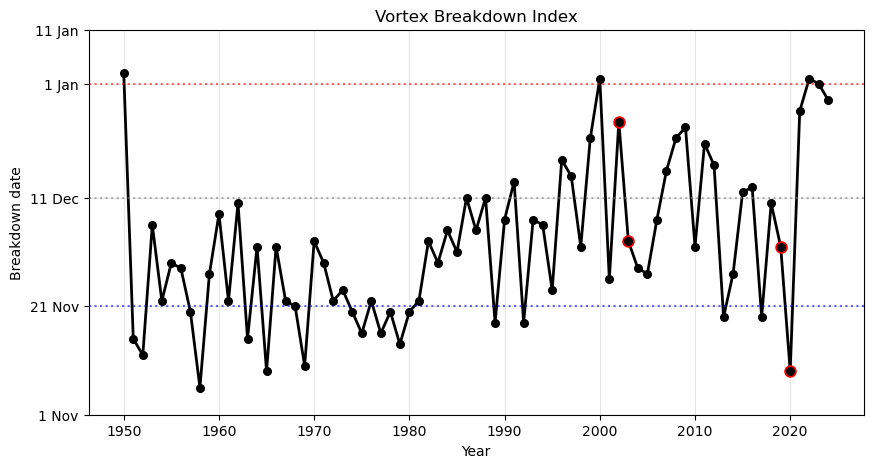

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dates = pd.to_datetime(breakdown_dates.values)
years = breakdown_dates["year"].values

valid = ~pd.isna(dates)
dates = dates[valid]
years = years[valid]

# sort chronologically
order = np.argsort(dates)
dates = dates[order]
years = years[order]

def wrapped_day(d):
    # shift year so Nov–Feb becomes continuous
    base_year = d.year if d.month >= 11 else d.year - 1
    start = pd.Timestamp(year=base_year, month=11, day=1)
    return (d - start).days


y = np.array([wrapped_day(d) for d in dates])

##add problematic years here as well
x_pos = [2002, 2020,2003,2019]
y_pos = [y[years == x][0] for x in x_pos]

plt.figure(figsize=(10,5))

# main line
plt.plot(years, y, color="black", linewidth=2)
plt.plot(x_pos, y_pos, 'o', color='red', markersize=8, label='Problematic Years')
# points
plt.scatter(years, y, color="black", s=30, zorder=3)

plt.xlabel("Year")
plt.ylabel("Breakdown date")
plt.title("Vortex Breakdown Index")

tick_dates = [
    pd.Timestamp("2001-11-01"),
    pd.Timestamp("2001-11-21"),
    pd.Timestamp("2001-12-11"),
    pd.Timestamp("2002-01-01"),
    pd.Timestamp("2002-01-11")
]

tick_pos = np.array([wrapped_day(d) for d in tick_dates])

plt.yticks(
    tick_pos,
    [d.strftime("%-d %b") for d in tick_dates]
)
plt.axhline(tick_pos[1], linestyle=":", color="blue", alpha=0.6)
plt.axhline(tick_pos[2], linestyle=":", color="gray", alpha=0.6)
plt.axhline(tick_pos[3], linestyle=":", color="red", alpha=0.6)
plt.grid(alpha=0.3)
plt.show()

<xarray.DataArray 'vortex_breakdown_date' (year: 75)> Size: 600B
array(['1950-01-03T11:30:00.000000000', '1950-11-15T11:30:00.000000000',
       '1951-11-12T11:30:00.000000000', '1952-12-06T11:30:00.000000000',
       '1953-11-22T11:30:00.000000000', '1954-11-29T11:30:00.000000000',
       '1955-11-28T11:30:00.000000000', '1956-11-20T11:30:00.000000000',
       '1957-11-06T11:30:00.000000000', '1958-11-27T11:30:00.000000000',
       '1959-12-08T11:30:00.000000000', '1960-11-22T11:30:00.000000000',
       '1961-12-10T11:30:00.000000000', '1962-11-15T11:30:00.000000000',
       '1963-12-02T11:30:00.000000000', '1964-11-09T11:30:00.000000000',
       '1965-12-02T11:30:00.000000000', '1966-11-22T11:30:00.000000000',
       '1967-11-21T11:30:00.000000000', '1968-11-10T11:30:00.000000000',
       '1969-12-03T11:30:00.000000000', '1970-11-29T11:30:00.000000000',
       '1971-11-22T11:30:00.000000000', '1972-11-24T11:30:00.000000000',
       '1973-11-20T11:30:00.000000000', '1974-11-16T11:30:00.000000000',
       '1975-11-22T11:30:00.000000000', '1976-11-16T11:30:00.000000000',
       '1977-11-20T11:30:00.000000000', '1978-11-14T11:30:00.000000000',
       '1979-11-20T11:30:00.000000000', '1980-11-22T11:30:00.000000000',
       '1981-12-03T11:30:00.000000000', '1982-11-29T11:30:00.000000000',
       '1983-12-05T11:30:00.000000000', '1984-12-01T11:30:00.000000000',
       '1985-12-11T11:30:00.000000000', '1986-12-05T11:30:00.000000000',
       '1987-12-11T11:30:00.000000000', '1988-11-18T11:30:00.000000000',
       '1989-12-07T11:30:00.000000000', '1990-12-14T11:30:00.000000000',
       '1991-11-18T11:30:00.000000000', '1992-12-07T11:30:00.000000000',
       '1993-12-06T11:30:00.000000000', '1994-11-24T11:30:00.000000000',
       '1995-12-18T11:30:00.000000000', '1996-12-15T11:30:00.000000000',
       '1997-12-02T11:30:00.000000000', '1998-12-22T11:30:00.000000000',
       '2000-01-02T11:30:00.000000000', '2000-11-26T11:30:00.000000000',
       '2001-12-25T11:30:00.000000000', '2002-12-03T11:30:00.000000000',
       '2003-11-28T11:30:00.000000000', '2004-11-27T11:30:00.000000000',
       '2005-12-07T11:30:00.000000000', '2006-12-16T11:30:00.000000000',
       '2007-12-22T11:30:00.000000000', '2008-12-24T11:30:00.000000000',
       '2009-12-02T11:30:00.000000000', '2010-12-21T11:30:00.000000000',
       '2011-12-17T11:30:00.000000000', '2012-11-19T11:30:00.000000000',
       '2013-11-27T11:30:00.000000000', '2014-12-12T11:30:00.000000000',
       '2015-12-13T11:30:00.000000000', '2016-11-19T11:30:00.000000000',
       '2017-12-10T11:30:00.000000000', '2018-12-02T11:30:00.000000000',
       '2019-11-09T11:30:00.000000000', '2020-12-27T11:30:00.000000000',
       '2022-01-02T11:30:00.000000000', '2023-01-01T11:30:00.000000000',
       '2023-12-29T11:30:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024

<xarray.DataArray 'dayofyear' ()> Size: 8B
array(75)
Coordinates:
    year     int64 8B 2024


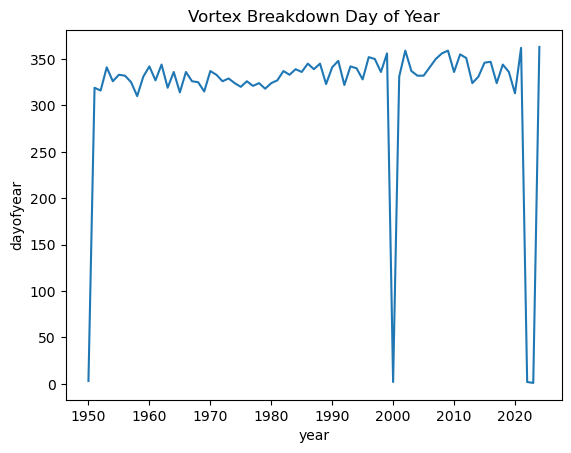

In [10]:
display(breakdown_dates)
##convert these into day of the year/Julian day
breakdown_doy = breakdown_dates.dt.dayofyear
breakdown_doy.plot()
plt.title('Vortex Breakdown Day of Year')
#print((breakdown_doy))
print(sum((~np.isnan(breakdown_doy))))

2002: 359
2003: 337
2019: 336
2020: 313


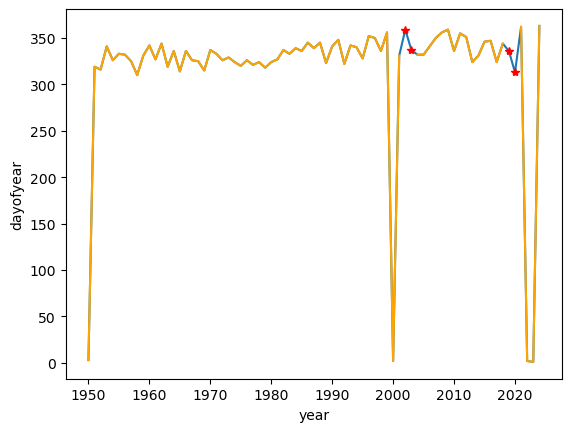

In [11]:
##exclude problematic years before detrending and averaging
#SSWs were in 2002 and 2019, first look at values for those years
print('2002:', breakdown_doy.sel(year=2002).values)
print('2003:', breakdown_doy.sel(year=2003).values)
print('2019:', breakdown_doy.sel(year=2019).values)
print('2020:', breakdown_doy.sel(year=2020).values)

x_pos = [2002, 2020,2003,2019]
y_pos = [breakdown_doy.sel(year=2002).values, breakdown_doy.sel(year=2020).values, breakdown_doy.sel(year=2003).values, breakdown_doy.sel(year=2019).values]
breakdown_doy.plot()
plt.plot(x_pos,y_pos,'r*')
plt.title('Vortex Breakdown Day of Year')

mask = ~breakdown_doy['year'].isin([2002, 2003, 2019, 2020])
breakdown_doy_masked = breakdown_doy.where(mask)
breakdown_doy_masked.plot(color='orange')

<xarray.DataArray ()> Size: 8B
array(71)
Coordinates:
    year     int64 8B 2024


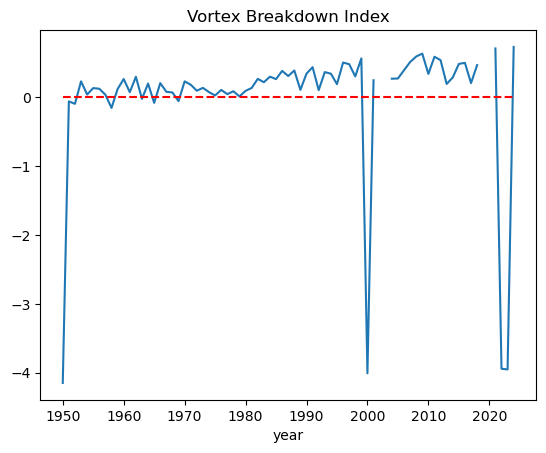

In [12]:
#detrend
p_vortex=breakdown_doy_masked.polyfit(dim='year', deg=1, skipna=True)
#print(p_vortex)
vortex_fit=xr.polyval(breakdown_doy_masked['year'], p_vortex.polyfit_coefficients)
vortex_detr=breakdown_doy_masked-vortex_fit

#normalise
VB_index=vortex_detr/vortex_detr.std(dim='year')
print(sum(~np.isnan(VB_index)))
VB_index.plot()
plt.hlines(VB_index.mean(), VB_index.year.min(), VB_index.year.max(), colors='r', linestyles='dashed')
plt.title('Vortex Breakdown Index')
plt.show()

IOBW computation

<xarray.Dataset> Size: 4MB
Dimensions:    (lat: 27, lon: 46, time: 901, nbnds: 2)
Coordinates:
  * lat        (lat) float32 108B -26.0 -24.0 -22.0 -20.0 ... 22.0 24.0 26.0
  * lon        (lon) float32 184B 30.0 32.0 34.0 36.0 ... 116.0 118.0 120.0
  * time       (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2025-01-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 14kB ...
    sst        (time, lat, lon) float32 4MB ...
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2025-02-03

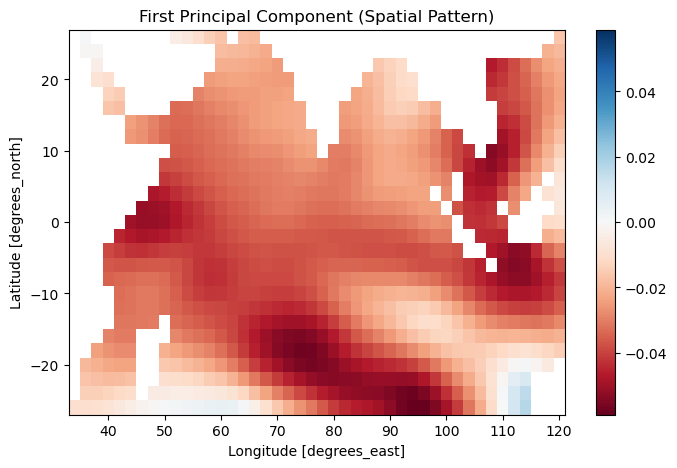

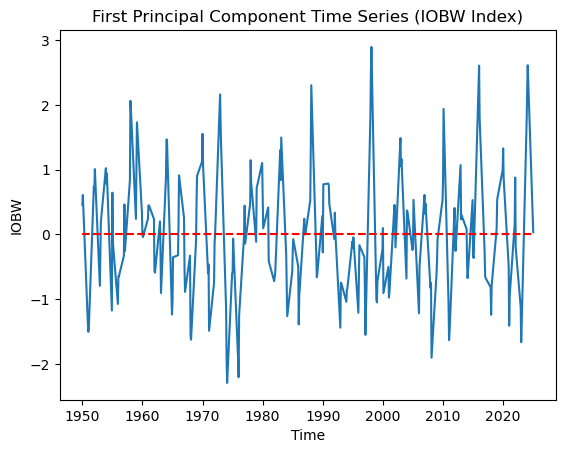

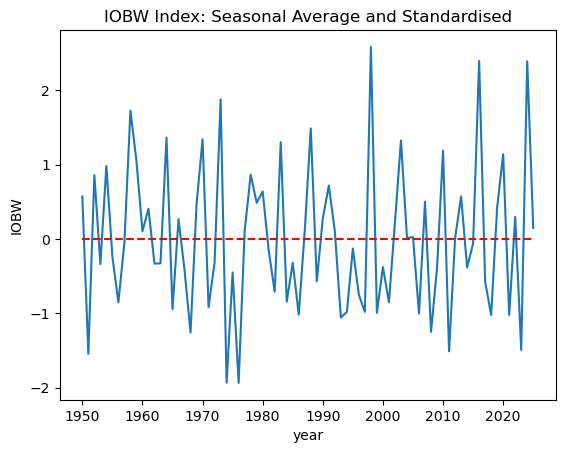

In [13]:
### Sea surface temperature, already monthly data
sst = xr.open_dataset('data/sst.mnmean.nc')
sst_io_whole=sst.sel(time=slice('1950','2025'),lat=slice(26,-26),lon=slice(30,120)).sortby('lat', ascending=True)
display(sst_io_whole)
#1 seasonal data extraction
sst_DJF=extract_seasonal_data(sst_io_whole, seasons=[12, 1, 2])
#2 compute anomaly
sst_DJF_anom=compute_anomaly(sst_DJF)['sst']

#detrend
p_sst=sst_DJF_anom.polyfit(dim='time', deg=1, skipna=True)
sst_fit=xr.polyval(sst_DJF_anom['time'], p_sst.polyfit_coefficients)
sst_detr=sst_DJF_anom-sst_fit
#print(sst_detr)
#3 compute PCs (including weight by latitude)
sst_DJF_anom_weighted=weight_by_latitude(sst_detr)


reshaped_sst_DJF=reshape_to_2d(sst_DJF_anom_weighted).dropna(dim='space', how='all') #drop any space points that are all NaN
#4 "SAM" procedure applied here
#cov_matrix=compute_covariance_matrix(reshaped_sst_DJF) not necessary?
#display(cov_matrix)
U, S, Vt=perform_svd(reshaped_sst_DJF)
pc_map_unstacked=plot_first_principal_component(reshaped_sst_DJF, Vt)
EOF1 = Vt[0, :]
EOF1_map = xr.DataArray(
    EOF1,
    coords={"space": reshaped_sst_DJF.space},
    dims=["space"]
).unstack("space")

PC1 = U[:, 0] * S[0] #index before normalisation
PC1_ts = xr.DataArray(
    PC1,
    coords={"time": reshaped_sst_DJF.time},
    dims=["time"],
    name="IOBW"
)
#multiply by -1 to match the sign of the IOBW index (positive = earlier breakdown)
PC1_ts = -PC1_ts
PC1_ts = (PC1_ts - PC1_ts.mean()) / PC1_ts.std()
PC1_ts.plot()
plt.hlines(PC1_ts.mean(), PC1_ts.time.min(), PC1_ts.time.max(), colors='r', linestyles='dashed')
plt.title('First Principal Component Time Series (IOBW Index)')
plt.show()

#seasonal averages and standardise again
IOBW_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(PC1_ts)))

IOBW_ssavg_DJF.plot()
plt.hlines(IOBW_ssavg_DJF.mean(), IOBW_ssavg_DJF.year.min(), IOBW_ssavg_DJF.year.max(), colors='r', linestyles='dashed')
plt.title('IOBW Index: Seasonal Average and Standardised')
plt.show()

Prepping both new indices and adding them to old data ready DJF

In [16]:
#1 exclude years
cut_years=[1950,2003,2020,2025]

def exclude_years_xr(xr_obj, years):
    return xr_obj.sel(year=~xr_obj.year.isin(years))

IOBW_ssavg_DJF=exclude_years_xr(IOBW_ssavg_DJF, cut_years)
VB_index=exclude_years_xr(VB_index, cut_years)

#convert to dataframe for adding to rest of indices
IOBW_df=IOBW_ssavg_DJF.to_dataframe()
VB_df=VB_index.to_dataframe(name='VB').dropna()

mask_early = VB_df['VB'] <= np.mean(VB_df['VB'])  # lower Julian day = earlier breakdown
mask_rest = ~mask_early
VB_df["VB_class"] = np.where(mask_early,
    "Early",
    "Late"
)


display(IOBW_df, VB_df)


,IOBW
year,
1951,-1.546450
1952,0.859070
1953,-0.337411
1954,0.982053
1955,-0.238466
...,...
2019,0.426333
2021,-1.023115
2022,0.296422


,VB,VB_class
year,,
1951,-0.065298,Early
1952,-0.100988,Early
1953,0.224743,Late
1954,0.034158,Early
1955,0.127547,Late
...,...,...
2018,0.460659,Late
2021,0.702102,Late
2022,-3.941701,Early


In [17]:
era_DJF_LaPlata_df=pd.read_csv('data_ready/6.csv',index_col='Unnamed: 0')
era_DJF_Andes_df=pd.read_csv('data_ready/4.csv',index_col='Unnamed: 0')

df1=pd.concat([era_DJF_LaPlata_df, IOBW_df, VB_df], axis=1)
df2=pd.concat([era_DJF_Andes_df, IOBW_df, VB_df], axis=1)

df1.to_csv('data_ready/6_with_IOBW_VB.csv')
df2.to_csv('data_ready/4_with_IOBW_VB.csv')

Adding Regime variable also to spring

In [1]:
era_SON_LaPlata_df=pd.read_csv('data_ready/7.csv',index_col='Unnamed: 0')
era_SON_Andes_df=pd.read_csv('data_ready/5.csv',index_col='Unnamed: 0')

df3=pd.concat([era_SON_LaPlata_df, VB_df], axis=1)
df4=pd.concat([era_SON_Andes_df, VB_df], axis=1)

df3.to_csv('data_ready/7_with_VB.csv')
df4.to_csv('data_ready/5_with_VB.csv')

NameError: name 'pd' is not defined

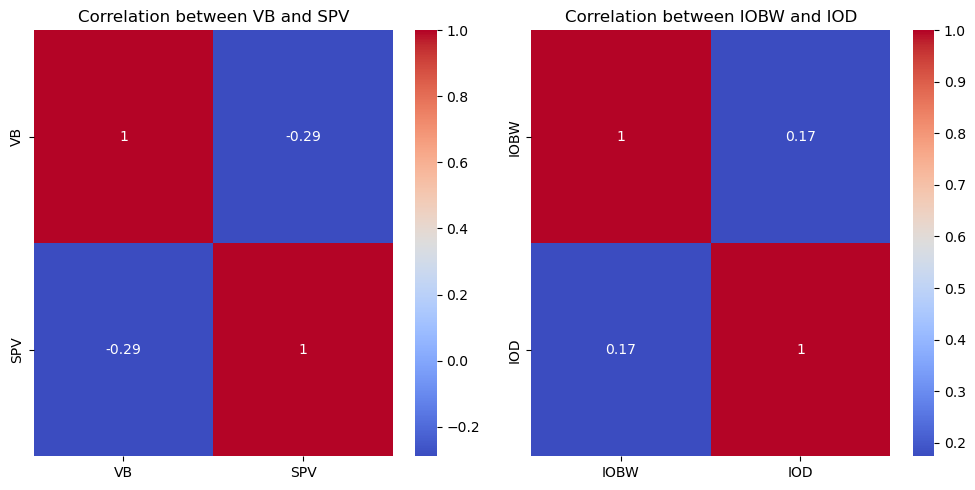

In [18]:
df_vortex=pd.concat([df1['VB'], df1['SPV']], axis=1)
df_io=pd.concat([df1['IOBW'], df1['IOD']], axis=1)

fig=plt.figure(figsize=(10, 5))
ax1=fig.add_subplot(1, 2, 1)
sns.heatmap(df_vortex.corr(), annot=True, cmap='coolwarm', ax=ax1)
ax1.set_title('Correlation between VB and SPV')
ax2=fig.add_subplot(1, 2, 2)
sns.heatmap(df_io.corr(), annot=True, cmap='coolwarm', ax=ax2)
ax2.set_title('Correlation between IOBW and IOD')
plt.tight_layout()
plt.savefig('new_summer_vars_correlation.jpg', dpi=300)
plt.show()